# **Assignment 1: The Value of Time**

_______________________________________________________________________

## **Imports**

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import root_scalar
from IPython.display import Markdown, display
from scipy.interpolate import CubicSpline

# Format fonts
np.seterr(divide='ignore', invalid='ignore')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Palatino"
})

## **Helper Functions**

In [65]:
# Define function to calculate residual between market dirty price and model dirty price given a YTM:

def residual(ytm, dirty_price, coupon_payment, face_value, terms_to_maturity):

    """Calculate residual = Dirty price - DCF(ytm)

    Args:
        ytm (float): Yield to maturity as a decimal.
        dirty_price (float): Market dirty price of the bond.
        coupon_payment (float): Annual coupon payment of the bond.
        terms_to_maturity (array-like): Times from price observation date to each coupon payment date in years.
    Returns:
        float: Residual between market dirty price and discounted cash flow with given ytm.
    """
        
    # Calculate present value of coupon payments:
    PV_rem_coupons = np.sum((coupon_payment / 2) / (1 + ytm / 2) ** (2 * terms_to_maturity[:-1]))
    
    # Calculate present value of face value and final coupon:
    PV_face_value = (coupon_payment / 2 + face_value) / (1 + ytm / 2) ** (2 * terms_to_maturity[-1])
    
    # Calculate discounted cash flows with given ytm:
    disc_cf = PV_rem_coupons + PV_face_value
    
    return dirty_price - disc_cf

__________________________________

## **Read in and Preprocess Data**

Recall from Question 2.2 (a) that our chosen bonds are as follows:

CAN 0.25 Mar. 01, 26 

CAN 1.0 Sep. 01, 26

CAN 1.25 Mar. 01, 27

CAN 2.75 Sep. 01, 27

CAN 3.5 Mar. 01, 28

CAN 3.25 Sep. 01, 28

CAN 4.0 Mar. 01, 29

CAN 3.5 Sep. 01, 29

CAN 2.75 Mar. 01, 30

CAN 2.75 Sep. 01, 30

CAN 2.75 Mar. 01, 31


### **Preprocess Bond Specifications Data**

In [66]:
############### Clean bond specification data: ###############

# Read in bond specification data:
bond_spec_df = pd.read_csv('bond_spec_data.csv')

# Convert date columns to datetime:
for date_col in ['Maturity Date', 'Issue Date', 'Coupon Start Date', 'Final Coupon Date']:
    bond_spec_df[date_col] = pd.to_datetime(bond_spec_df[date_col])

# Convert percentage to decimals for coupon rates:
bond_spec_df['Coupon'] = bond_spec_df['Coupon'].str.rstrip('%').astype(float) / 100 

# Get ISIN of chosen bonds:
ISINs = bond_spec_df.loc[bond_spec_df["Maturity Date"].dt.month.isin([3, 9]) 
                         & (bond_spec_df['Maturity Date'].dt.year <= 2031), "ISIN"]

# Filter bond spec data for chosen ISINs:
bond_spec_df = bond_spec_df[bond_spec_df['ISIN'].isin(ISINs)]

# Keep only relevant columns:
spec_cols = ['ISIN',
             'Coupon',
             'Denomination',
             'Maturity Date',
             'Coupon Start Date',
             'Final Coupon Date']

bond_spec_df = bond_spec_df[spec_cols].reset_index(drop=True)

# Rename columns for clarity:
bond_spec_df = bond_spec_df.rename(columns={"Coupon": "Coupon Rate",
                                            "Denomination": "Face Value"})

# Add (annual) coupon payment amount column:
bond_spec_df.insert(loc=3, column='Coupon Payment', value=bond_spec_df['Coupon Rate'] * bond_spec_df['Face Value'])

display(Markdown("### **Bond Specification Data**"))
display(bond_spec_df)

### **Bond Specification Data**

,ISIN,Coupon Rate,Face Value,Coupon Payment,Maturity Date,Coupon Start Date,Final Coupon Date
0,CA135087L518,0.0025,1000,2.5,2026-03-01,2021-03-01,2026-02-28
1,CA135087L930,0.0100,1000,10.0,2026-09-01,2021-09-01,2026-08-31
2,CA135087M847,0.0125,1000,12.5,2027-03-01,2022-03-01,2027-02-28
3,CA135087N837,0.0275,1000,27.5,2027-09-01,2022-09-01,2027-08-31
4,CA135087P576,0.0350,1000,35.0,2028-03-01,2023-03-01,2028-02-29
5,CA135087Q491,0.0325,1000,32.5,2028-09-01,2023-09-01,2028-08-31
6,CA135087Q988,0.0400,1000,40.0,2029-03-01,2024-03-01,2029-02-28
7,CA135087R895,0.0350,1000,35.0,2029-09-01,2024-09-01,2029-08-31
8,CA135087S471,0.0275,1000,27.5,2030-03-01,2025-03-01,2030-02-28
9,CA135087T388,0.0275,1000,27.5,2030-09-01,2025-09-01,2030-08-31


### **Preprocess Bond Specifications Data**

In [67]:
############### Clean bond price data: ###############  

# Read in bond price data:
bond_price_df = pd.read_csv('bond_price_data.csv')

# Convert date column to datetime:
bond_price_df['date'] = pd.to_datetime(bond_price_df['date'])

# Filter price data for chosen ISINs:
bond_price_df = bond_price_df[bond_price_df['ISIN'].isin(ISINs)]

# Filter price data for final price in each day:
bond_price_df = bond_price_df[bond_price_df['date'].dt.hour > 20].reset_index(drop=True)

# Keep only relevant columns:
price_cols = ['ISIN', 'date', 'close']
bond_price_df = bond_price_df[price_cols].reset_index(drop=True)

# Rename columns for clarity:
bond_price_df = bond_price_df.rename(columns={"close": "Quoted Price",
                                              "date": "Date"})

# Add Clean Price column (Note: Clean Price = Quoted Price * Face Value / 100 as quoted price is quoted relative to par (face value)):
bond_price_df['Clean Price'] = bond_price_df['Quoted Price'] * bond_spec_df.set_index('ISIN').loc[bond_price_df['ISIN'], 'Face Value'].values / 100

display(Markdown("### **Bond Price Data**"))
display(bond_price_df)

### **Bond Price Data**

,ISIN,Date,Quoted Price,Clean Price
0,CA135087L518,2026-01-05 22:44:00,99.700,997.00
1,CA135087L518,2026-01-06 22:44:00,99.710,997.10
2,CA135087L518,2026-01-07 22:44:00,99.710,997.10
3,CA135087L518,2026-01-08 22:44:00,99.720,997.20
4,CA135087L518,2026-01-09 22:44:00,99.730,997.30
...,...,...,...,...
116,CA135087T792,2026-01-13 22:44:00,98.838,988.38
117,CA135087T792,2026-01-14 22:44:00,99.033,990.33
118,CA135087T792,2026-01-15 22:44:00,99.043,990.43
119,CA135087T792,2026-01-16 22:44:00,98.968,989.68


### **Merge Bond Price and Specification Data**

In [68]:
# Merge bond specification and price data:
bond_data_df = bond_price_df.merge(
        bond_spec_df,
        on="ISIN",
        how="left",
        validate="many_to_one"  
    )

############### Calculate accrued interest and dirty price: ###############

accrued_interest = []

# Loop through each row of the merged data frame to calculate accrued interest for each bond price observation:
for i, row in bond_data_df.iterrows():
    
    # Coupon dates are every 6 months from the coupon start date to the final coupon date (inclusive):
    coupon_dates = pd.date_range(start=row['Coupon Start Date'],
                                 end=row['Final Coupon Date'],
                                 freq=pd.DateOffset(months=6)).union(pd.DatetimeIndex([row["Final Coupon Date"]]))

    # No accrued interest if price observation is before first coupon date:
    if row['Date'] < coupon_dates[0]:
        accrued_interest.append(0)
        continue
    
    # Calculate most recent coupon date prior to price observation date:
    most_recent_coupon_date = coupon_dates[coupon_dates <= row['Date']].max()

    # Calculate accrued interest:
    days_since_coupon = (row['Date'] - most_recent_coupon_date).days
    accrued_interest.append((row['Coupon Payment']/2) * (days_since_coupon / (365/2)))  # Assuming semi-annual coupon payment
    
accrued_interest = np.array(accrued_interest)

# Add Accrued Interest and Dirty Price columns (Dirty Price = Clean Price + Accrued Interest) to data frame:
bond_data_df['Accrued Interest'] = accrued_interest
bond_data_df['Dirty Price'] = bond_data_df['Clean Price'] + accrued_interest
    
# Reorder columns for clarity:
bond_data_df = bond_data_df[['ISIN', 
                             'Date',
                             'Face Value',
                             'Coupon Rate',
                             'Coupon Payment',
                             'Quoted Price', 
                             'Clean Price', 
                             'Accrued Interest', 
                             'Dirty Price', 
                             'Maturity Date',
                             'Coupon Start Date',
                             'Final Coupon Date']]    

display(Markdown("### **Bond  Data**"))
display(Markdown("##### **Note:** Coupon Rates and Coupon Payments are annualized"))
display(bond_data_df)

### **Bond  Data**

##### **Note:** Coupon Rates and Coupon Payments are annualized

,ISIN,Date,Face Value,Coupon Rate,Coupon Payment,Quoted Price,Clean Price,Accrued Interest,Dirty Price,Maturity Date,Coupon Start Date,Final Coupon Date
0,CA135087L518,2026-01-05 22:44:00,1000,0.0025,2.5,99.700,997.00,0.863014,997.863014,2026-03-01,2021-03-01,2026-02-28
1,CA135087L518,2026-01-06 22:44:00,1000,0.0025,2.5,99.710,997.10,0.869863,997.969863,2026-03-01,2021-03-01,2026-02-28
2,CA135087L518,2026-01-07 22:44:00,1000,0.0025,2.5,99.710,997.10,0.876712,997.976712,2026-03-01,2021-03-01,2026-02-28
3,CA135087L518,2026-01-08 22:44:00,1000,0.0025,2.5,99.720,997.20,0.883562,998.083562,2026-03-01,2021-03-01,2026-02-28
4,CA135087L518,2026-01-09 22:44:00,1000,0.0025,2.5,99.730,997.30,0.890411,998.190411,2026-03-01,2021-03-01,2026-02-28
...,...,...,...,...,...,...,...,...,...,...,...,...
116,CA135087T792,2026-01-13 22:44:00,1000,0.0275,27.5,98.838,988.38,0.000000,988.380000,2031-03-01,2026-03-01,2031-02-28
117,CA135087T792,2026-01-14 22:44:00,1000,0.0275,27.5,99.033,990.33,0.000000,990.330000,2031-03-01,2026-03-01,2031-02-28
118,CA135087T792,2026-01-15 22:44:00,1000,0.0275,27.5,99.043,990.43,0.000000,990.430000,2031-03-01,2026-03-01,2031-02-28
119,CA135087T792,2026-01-16 22:44:00,1000,0.0275,27.5,98.968,989.68,0.000000,989.680000,2031-03-01,2026-03-01,2031-02-28


___________________________________________

## **4.**

## **(a) Yield Curve Construction**

In this section, we compute the yields of the 11 considered bonds on each trading day and plot the associated curves.


We consider the $N$ coupon payment dates $t_0 < \cdots < t_{N} < T$ associated to the longest dated bond and let the **Final Coupon Date** of bond $i$ be indexed by $N_i$, i.e. the **Final Coupon Date** of bond $i$ is $t_{N_i}$. This is valid as, given our choice of bonds, we have that the set of coupon dates of the longest dated bond contains all coupon dates of the earlier dated bonds. We let $R_i$ denote the (annual) **Coupon Rate** and hence have the annual **Coupon Payment** $C_i := F \cdot R_i$ where $F$ denotes the **Face Value** of the bond (note that all bonds selected share a common face value $F = 1000\, \mathrm{CAD}$). For a given trading day $t\in (t_{N_1-1}, t_{N_1}]$ (all considered trading days lie in this window), the **Yield-to-Maturity** of bond $i$ on trading day $t$ is denoted $y_i(t)$ and is defined by the following relation:
$$
P_i(t) =  \sum_{j = k}^{N_i-1} \frac{C_i/2}{(1 + \frac{y_i(t)}{2})^{2\tau_j}} + \frac{F + C_i/2}{(1 + \frac{y_i(t)}{2})^{2\tau_{N_i}}},
$$
where $\tau_j := t_j - t$ for $j\geq N_1$, and $P_i(t)$ is the dirty (close) price of bond $i$ on trading day $t$. 

In [69]:
# Add yield-to-maturity column by finding root of residual function for each row:
for i, row in bond_data_df.iterrows():
    
    # Calculate terms to maturity for each coupon payment date:
    coupon_dates = pd.date_range(start=row['Coupon Start Date'],
                                 end=row['Final Coupon Date'],
                                 freq=pd.DateOffset(months=6)).union(pd.DatetimeIndex([row["Final Coupon Date"]]))
    
    terms_to_maturity = (coupon_dates - row['Date']).days / 365  # Convert to years
    
    # Consider only future coupon payments for yield calculation:
    terms_to_maturity = terms_to_maturity[terms_to_maturity > 0]
    
    # Find root of residual function to find yield-to-maturity:
    ytm = root_scalar(residual, 
                      args=(row['Dirty Price'], row['Coupon Payment'], row['Face Value'], terms_to_maturity), 
                      bracket=[0, 1], 
                      method='bisect').root
   
    
    bond_data_df.loc[i, 'Yield to Maturity'] = ytm
    

# Report yields for bonds across trading dates:
ytm_df = (
    bond_data_df.pivot_table(
        index="Maturity Date",
        columns="Date",
        values="Yield to Maturity",
        aggfunc="first"
    )
    .sort_index(axis=0)  
    .sort_index(axis=1)
)

ytm_df.index = ytm_df.index.strftime("%Y-%m-%d")
ytm_df.columns = ytm_df.columns.strftime("%Y-%m-%d")

# Report summary statistics for yield to maturity:
display(Markdown("### **Yield-to-Maturity Summary Statistics**"))
ytm_df


### **Yield-to-Maturity Summary Statistics**

Date,2026-01-05,2026-01-06,2026-01-07,2026-01-08,2026-01-09,2026-01-12,2026-01-13,2026-01-14,2026-01-15,2026-01-16,2026-01-19
Maturity Date,,,,,,,,,,,
2026-03-01,0.023473,0.023166,0.023573,0.023257,0.022928,0.023462,0.023931,0.023579,0.023212,0.022827,0.023450
2026-09-01,0.023421,0.023478,0.023219,0.023355,0.022933,0.023264,0.023159,0.023054,0.022947,0.022840,0.023096
2027-03-01,0.025076,0.024836,0.024594,0.024533,0.024562,0.024649,0.024587,0.024709,0.024186,0.024307,0.024302
2027-09-01,0.026211,0.025710,0.025832,0.025642,0.025702,0.025568,0.025691,0.025625,0.025369,0.025239,0.025483
2028-03-01,0.026760,0.026512,0.026502,0.026396,0.026433,0.026305,0.026439,0.026284,0.026129,0.026166,0.026279
2028-09-01,0.027256,0.026977,0.027011,0.026888,0.026922,0.026788,0.026900,0.026855,0.026653,0.026687,0.026749
2029-03-01,0.027952,0.027714,0.027671,0.027563,0.027585,0.027457,0.027578,0.027436,0.027327,0.027350,0.027451
2029-09-01,0.028577,0.028257,0.028138,0.028219,0.028300,0.028171,0.028339,0.028219,0.027927,0.027951,0.028225
2030-03-01,0.028846,0.029028,0.028667,0.028836,0.028625,0.028762,0.028828,0.028426,0.028414,0.028544,0.028625


##### **Plot Yield Curve**

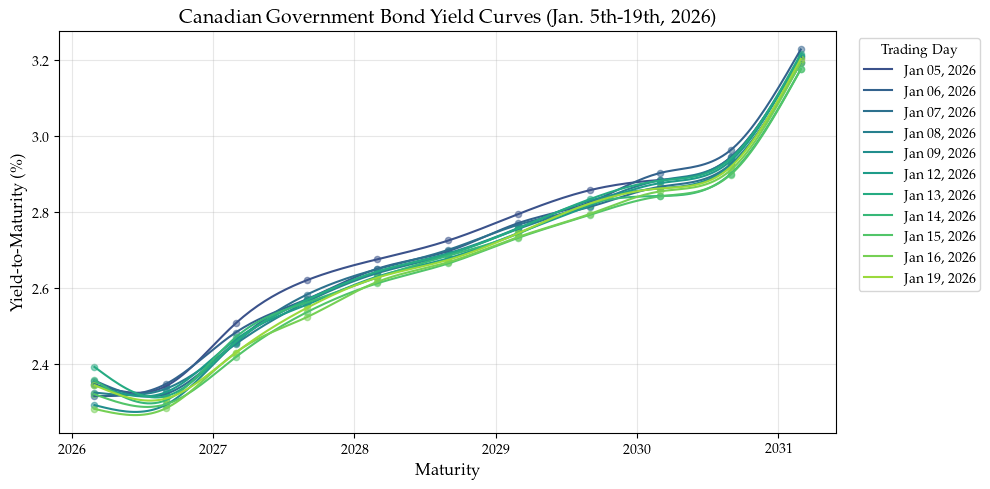

In [70]:
fig, axs = plt.subplots(figsize=(10, 5))
trading_dates = np.sort(bond_data_df["Date"].unique()) 
coupon_dates = bond_data_df['Final Coupon Date'].unique()
vals = np.linspace(0.25, 0.85, len(trading_dates))
cmap = dict(zip(trading_dates, [plt.cm.viridis(v) for v in vals]))
yield_curves = np.full((len(trading_dates), len(coupon_dates)), np.nan)

for i, date in enumerate(trading_dates):
    
    bond_subset = bond_data_df[bond_data_df['Date'] == date]
    maturities = bond_subset['Final Coupon Date']

    x = (maturities - date).dt.days / 365  
    y = 100 * bond_subset['Yield to Maturity']  
    yield_curves[i, :] = y.values
    
    # Interpolate using natural cubic spline:
    cs = CubicSpline(x, y, bc_type='natural')
    x_smooth = np.linspace(x.min(), x.max(), 200)
    y_smooth = cs(x_smooth)
    
    # Convert (smoothed) year fraction from date to corresponding maturity:
    date = pd.Timestamp(date)
    maturity_smooth = date + pd.to_timedelta(x_smooth * 365, unit="D")
    
    axs.scatter(maturities, y, s=20, alpha=0.5, color=cmap[date])
    axs.plot(maturity_smooth, y_smooth, label=date.strftime('%b %d, %Y'), color=cmap[date])    
    
axs.set_xlabel('Maturity', fontsize=12)
axs.set_ylabel('Yield-to-Maturity (\%)', fontsize=12)
axs.set_title('Canadian Government Bond Yield Curves (Jan. 5th-19th, 2026)', fontsize=14)
axs.legend(title='Trading Day', bbox_to_anchor=(1.02, 1), loc='upper left')
axs.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("YieldCurves.pdf", bbox_inches="tight")
plt.show()

________________________________________

## **(b) Spot Curve Construction**

In this section, we construct the market spot curve on each trading day by bootstrapping the prices of our 11 considered bonds with staggered maturities.

We consider the $N$ coupon payment dates $t_0 < \cdots < t_{N} < T$ associated to the longest dated bond and let the **Final Coupon Date** of bond $i$ be indexed by $N_i$, i.e. the **Final Coupon Date** of bond $i$ is $t_{N_i}$. This is valid as, given our choice of bonds, we have that the set of coupon dates of the longest dated bond contains all coupon dates of the earlier dated bonds. We let $R_i$ denote the (annual) **Coupon Rate** and hence have the annual **Coupon Payment** $C_i := F \cdot R_i$ where $F$ denotes the **Face Value** of the bond (note that all bonds selected share a common face value $F = 1000\, \mathrm{CAD}$). For a given trading day $t\in (t_{N_1-1}, t_{N_1}]$ (all considered trading days lie in this window), and for each $j\geq N_1$, we denote the **spot rate** at term $t_j$ at time $t$ by $r(t, t_j)$ and can compute each spot rate in an inductive fashion via the following bootstrap procedure:


$$
P_1(t) = \frac{C_1/2 + F}{(1 + r(t, t_{N_1}))^{\tau_{N_1}}},
$$
and, for $2\leq i\leq 11$,

$$
P_i(t) =  \sum_{j = N_1}^{N_i-1} \frac{C_i/2}{(1 + r(t, t_j))^{\tau_{j}}} + \frac{F + C_i/2}{(1 + r(t, t_{N_i}))^{\tau_{N_i}}},
$$

where $\tau_j := t_j - t$ and $P_i(t)$ denotes the dirty price of bond $i$ at time $t$. The explicit recursive relationship, assuming $r(t, t_j)$ is known for $j = N_1, \dots, N_i-1$, is then given by:
$$
r(t, t_{N_{i}})
=
\left(
\frac{F + C_i/2}{
P_i(t) - \displaystyle\sum_{j=N_1}^{N_i-1}
\frac{C_i/2}{(1 + r(t, t_j))^{\tau_j}}
}
\right)^{1/\tau_{N_i}} - 1.
$$


In [ ]:
trading_dates = bond_data_df["Date"].unique()
coupon_dates = bond_data_df['Final Coupon Date'].unique()
spot_curves = np.zeros((len(trading_dates), len(coupon_dates)))

for i, date in enumerate(trading_dates):

    # Get terms to maturity for each coupon date from price observation date:
    remaining_coupon_dates = coupon_dates[coupon_dates > date]
    num_remaining_coupons = len(remaining_coupon_dates)
    tau = (remaining_coupon_dates - date).days / 365  
        
    ######### Get spot rate at first coupon date: ########
    
    # Get coupon payment, face value, and dirty price for bond maturing at first remaining coupon date:
    first_bond_info = bond_data_df[(bond_data_df['Date'] == date) & (bond_data_df['Final Coupon Date'] == remaining_coupon_dates[0])].iloc[0]      
    C, F, P = first_bond_info['Coupon Payment'], first_bond_info['Face Value'], first_bond_info['Dirty Price']
            
    # Get spot rate at first coupon date:
    spot_curves[i, 0] = ((F + C/2) / P) ** (1/tau[0]) - 1
    
    ###################################
    
    # Calculate spot rates at later coupon dates using bootstrapping:
    
    # Loop over remaining coupon dates:
    for j in range(1, num_remaining_coupons):
        
        # Get coupon payment and face value for bond maturing at remaining_coupon_dates[j]:
        bond_info = bond_data_df[(bond_data_df['Date'] == date) & (bond_data_df['Final Coupon Date'] == remaining_coupon_dates[j])].iloc[0]
        
        C = bond_info['Coupon Payment']  
        F = bond_info['Face Value']
        P = bond_info['Dirty Price']
        
        # Calculate present value of coupon payments discounted at previously calculated spot rates:
        PV_coupons = np.sum((C / 2) / (1 + spot_curves[i, :j]) ** (tau[:j]))
        residual = P - PV_coupons

        # Calculate spot rate at next date via bootstrap:
        spot_curves[i, j] = ((F + C/2) / residual) ** (1/tau[j]) - 1


##### **Plot Spot Curve**

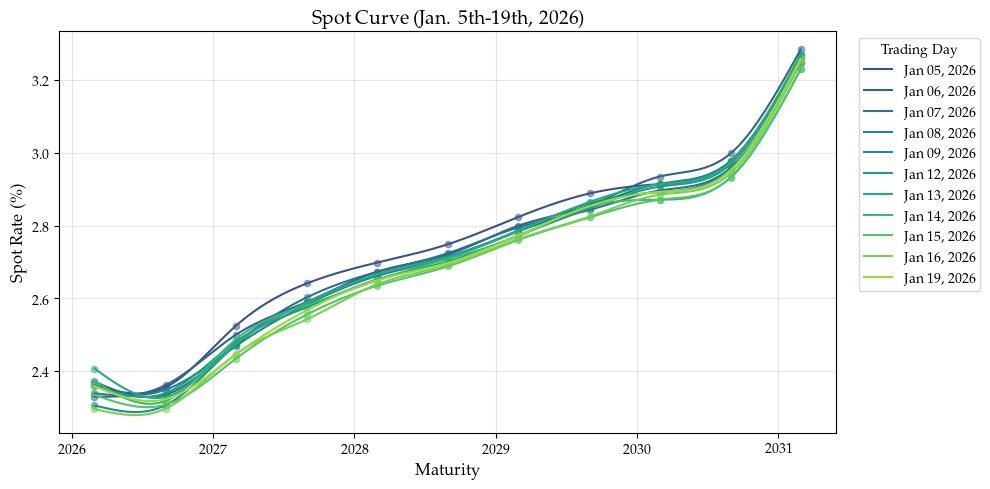

In [72]:
fig, axs = plt.subplots(figsize=(10, 5))
trading_dates = np.sort(bond_data_df["Date"].unique()) 
vals = np.linspace(0.25, 0.85, len(trading_dates))
cmap = dict(zip(trading_dates, [plt.cm.viridis(v) for v in vals]))

for i, date in enumerate(trading_dates):
    
    bond_subset = bond_data_df[bond_data_df['Date'] == date]
    maturities = bond_subset['Final Coupon Date']

    x = (maturities - date).dt.days / 365  
    y = 100 * spot_curves[i,:]
    
    # Interpolate using natural cubic spline:
    cs = CubicSpline(x, y, bc_type='natural')
    x_smooth = np.linspace(x.min(), x.max(), 200)
    y_smooth = cs(x_smooth)
    
    # Convert (smoothed) year fraction from date to corresponding maturity:
    date = pd.Timestamp(date)
    maturity_smooth = date + pd.to_timedelta(x_smooth * 365, unit="D")
    
    # Plot spot curve on given date:
    axs.scatter(maturities, y, s=20, alpha=0.5, color=cmap[date])
    axs.plot(maturity_smooth, y_smooth, label=date.strftime('%b %d, %Y'), color=cmap[date])    
    
axs.set_xlabel('Maturity', fontsize=12)
axs.set_ylabel('Spot Rate (\%)', fontsize=12)
axs.set_title('Spot Curve (Jan. 5th-19th, 2026)', fontsize=14)
axs.legend(title='Trading Day', bbox_to_anchor=(1.02, 1), loc='upper left')
axs.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("SpotCurves.pdf", bbox_inches="tight")   # best for LaTeX
plt.show()

________________________________________

### **(c) Forward Curve Construction**

In this section, we construct the market forward curve on each trading day implied by the market spot curves constructed above. In particular, we construct the $1$-year forward curves with terms $2\text{-}5$ years, i.e. the $1\text{y-}1\text{y}$, $1\text{y-}2\text{y}$, $1\text{y-}3\text{y}$, $1\text{y-}4\text{y}$ forward rates on each trading date.

For each trading day $t$, we consider the (continuously interpolated) annual spot curve $T \mapsto r(t,T - t)$ formed by the cubic spline interpolation of the spot rates on each coupon date. In the previous section, the second argument of $r(t, \cdot)$ denoted maturity whereas it here denotes time-to-maturity for notational convenience. We then define the $1\text{yr}$-$n\text{yr}$ **forward rate** on trading day $t$, $F_t(1, n)$, for $n=1,2,3,4$ as follows:


$$

F_t(1,n) = \Bigl(\frac{(1 + r(t, 1 + n))^{(1+n)}}{(1 + r(t, 1))}\Bigl)^{\frac{1}{n}} - 1. 

$$



In [73]:
num_terms = 4
forward_curves = np.full((len(trading_dates), num_terms), np.nan)

# Loop over trading dates and calculate forward rates for each term:
for i, date in enumerate(trading_dates):
    
    # Construct cubic spline of spot curve for this date:
    maturities = bond_data_df['Final Coupon Date'].unique()
    x = (maturities - date).days / 365
    y = np.asarray(spot_curves[i,:], dtype=float)
    spot_curve = CubicSpline(x, y, bc_type='natural')
    
    # Terms for forward rates in years
    terms = np.array([2, 3, 4, 5])  
    spot_rates = spot_curve(terms)
    
    # Calculate forward rates using spot rates:
    forward_curves[i, :] = ((1 + spot_rates) ** terms / (1 + spot_curve(1))) ** (1 / (terms - 1)) - 1

##### **Plot 1y-Start Forward Curve**

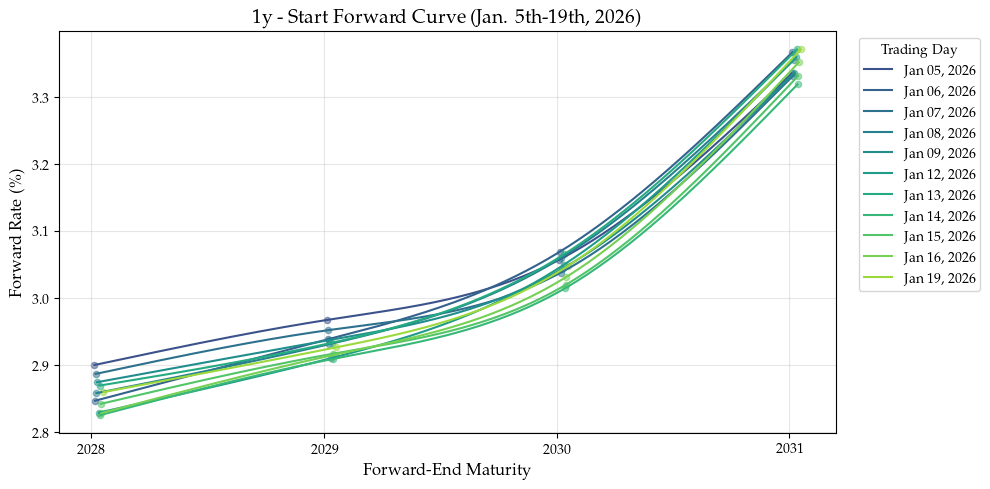

In [74]:
fig, axs = plt.subplots(figsize=(10, 5))
trading_dates = np.sort(bond_data_df["Date"].unique())
vals = np.linspace(0.25, 0.85, len(trading_dates))
cmap = dict(zip(trading_dates, [plt.cm.viridis(v) for v in vals]))

for i, date in enumerate(trading_dates):

    # 1y-1y, 1y-2y, 1y-3y, 1y-4y correspond to forward-end maturities 2y, 3y, 4y, 5y from trading date:
    x = np.array([2, 3, 4, 5], dtype=float)
    y = 100 * forward_curves[i, :]

    # Interpolate using natural cubic spline:
    cs = CubicSpline(x, y, bc_type='natural')
    x_smooth = np.linspace(x.min(), x.max(), 200)
    y_smooth = cs(x_smooth)

    # Convert (smoothed) year fraction from date to corresponding maturity:
    date = pd.Timestamp(date)
    maturities = date + pd.to_timedelta(x * 365, unit="D")
    maturity_smooth = date + pd.to_timedelta(x_smooth * 365, unit="D")

    axs.scatter(maturities, y, s=20, alpha=0.5, color=cmap[date])
    axs.plot(maturity_smooth, y_smooth, label=date.strftime('%b %d, %Y'), color=cmap[date])

axs.set_xlabel('Forward-End Maturity', fontsize=12)
axs.set_ylabel('Forward Rate (\%)', fontsize=12)
axs.set_title('1y\ - Start Forward Curve (Jan. 5th-19th, 2026)', fontsize=14)
axs.legend(title='Trading Day', bbox_to_anchor=(1.02, 1), loc='upper left')
axs.xaxis.set_major_locator(mdates.YearLocator())
axs.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axs.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ForwardCurves.pdf", bbox_inches="tight")   # best for LaTeX
plt.show()

________________________________

## **5.**

As in 4. (b), we consider the $N$ coupon payment dates $t_0 < \cdots < t_{N} < T$ associated to the longest dated bond and let the **Final Coupon Date** of bond $i$ be indexed by $N_i$, i.e. the **Final Coupon Date** of bond $i$ is $t_{N_i}$. This is valid as, given our choice of bonds, we have that the set of coupon dates of the longest dated bond contains all coupon dates of the earlier dated bonds. We let $T_j$, for $j=1,...,11$ denote the trading dates and consider the log-returns of the yield and spot rates on each final coupon date. In the notation of $4.$, we define:

$$
X_{i,j} = \log\Bigl(\frac{y_{i}(T_{j+1})}{y_{i}(T_{j})}\Bigl), \ \ \ j=1,...,10,
$$
as the log-returns of the yield-to-maturity for bond $i$, and similarly define:
$$
Y_{i,j} = \log\Bigl(\frac{r(T_{j+1}, t_{N_i})}{r(T_{j}, t_{N_i})}\Bigl), \ \ \ j=1,...,10,
$$
as the log-returns of the spot rate at node $i$, or maturity $t_{N_i}$. We then view each $X_{i,j}$ and $Y_{i,j}$ as i.i.d. of the random variables $X_i$ and $Y_i$ respectively, and use these samples to produce sample covariance matrices for the random vectors $(X_1,...,X_{11})$ and $(Y_1,...,Y_{11})$.

In [75]:
# Create design matrices for log-returns of yield curves, spot curves, and forward curves:
X = np.log(yield_curves[1:, :] / yield_curves[:-1, :])
Y = np.log(spot_curves[1:, :] / spot_curves[:-1, :])
Z = np.log(forward_curves[1:, :] / forward_curves[:-1, :])

# Construct covariance and correlation matrices:
cov_X, corr_X = np.cov(X, rowvar=False), np.corrcoef(X, rowvar=False)
cov_Y, corr_Y = np.cov(Y, rowvar=False), np.corrcoef(Y, rowvar=False)
cov_Z, corr_Z = np.cov(Z, rowvar=False), np.corrcoef(Z, rowvar=False)

#### **Plot Covariance and Correlation Matrix Heatmaps**

/var/folders/gl/z1zvfk1s4gj_1d_f68c5nmy80000gn/T/ipykernel_1569/120145812.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


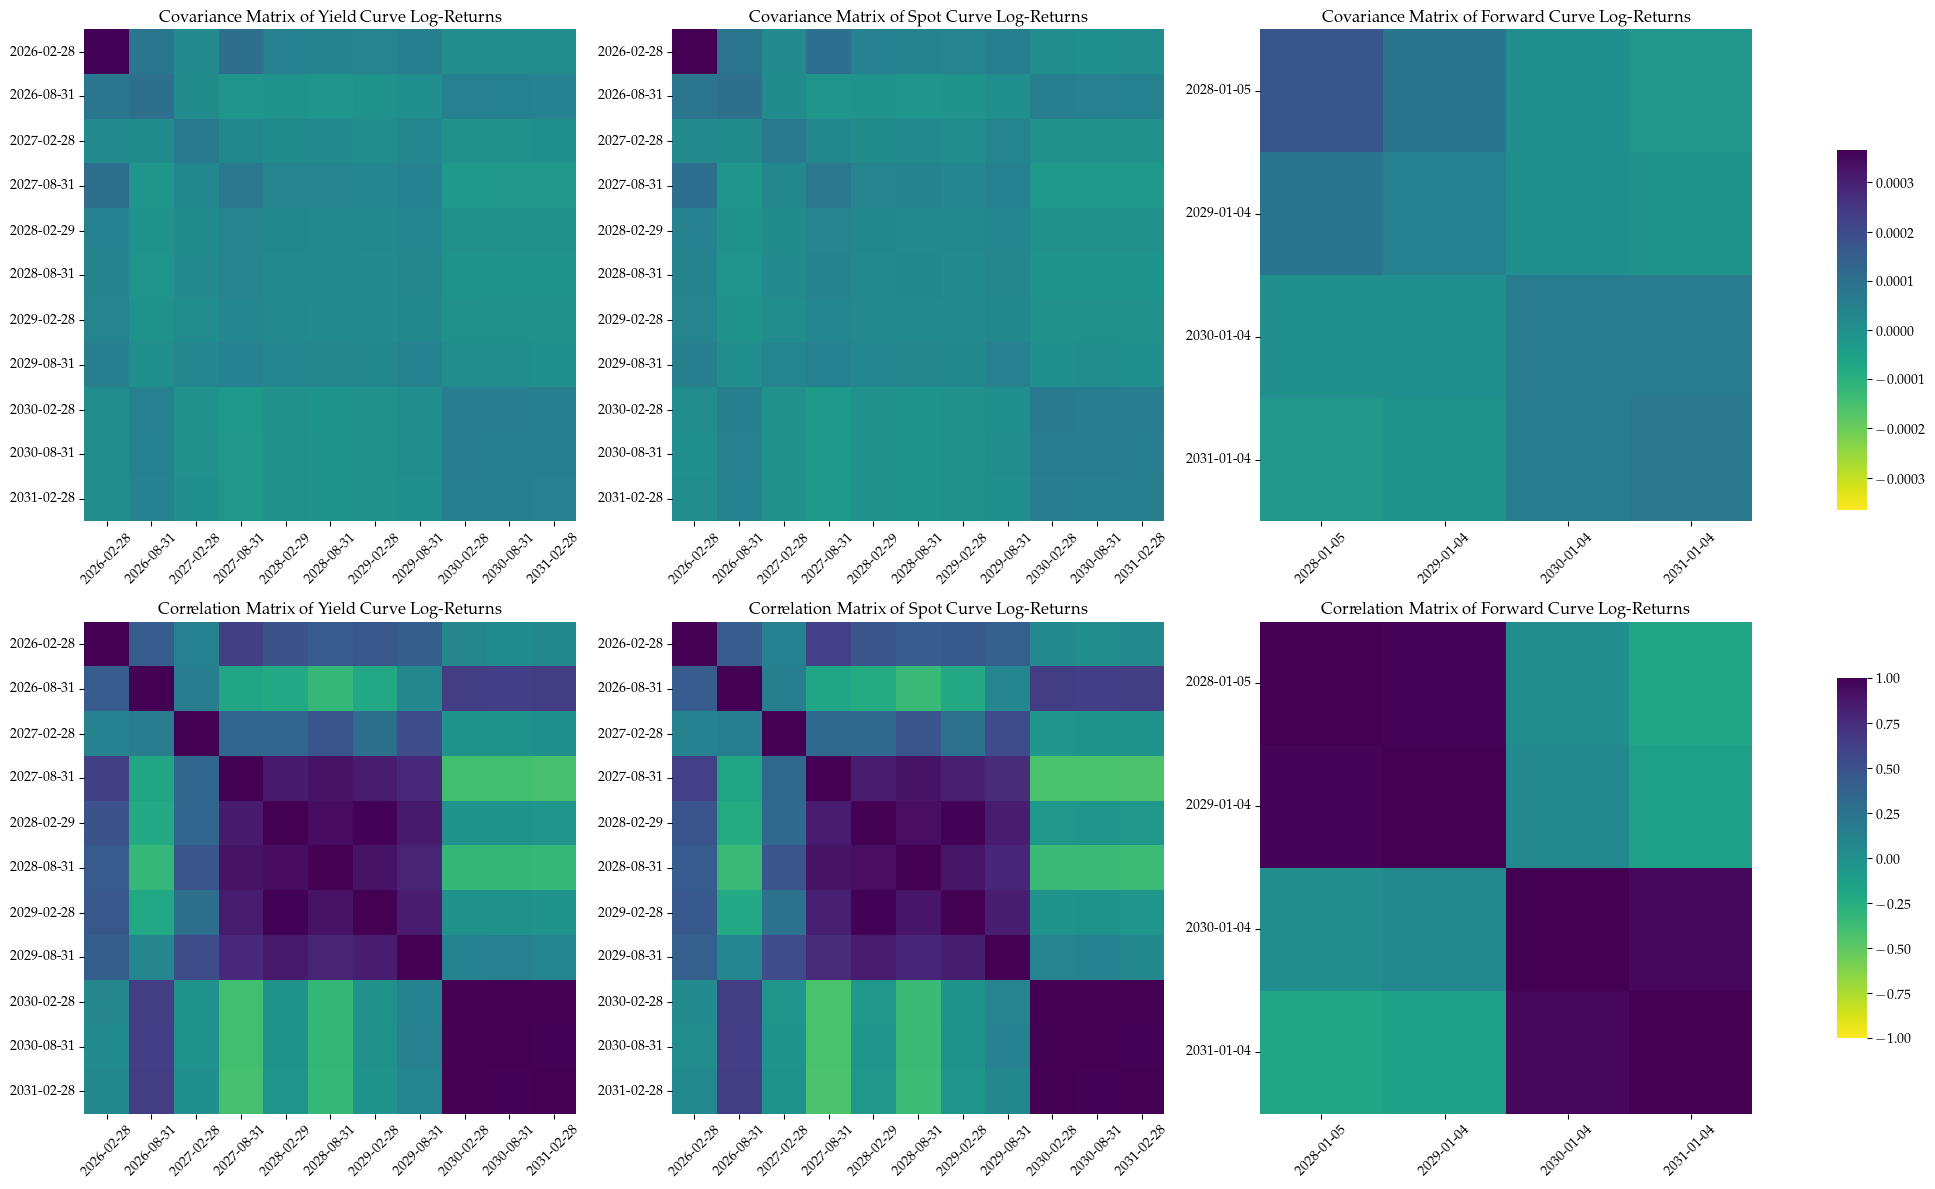

In [76]:
cmap = 'viridis_r'
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.subplots_adjust(right=0.9, hspace=0.35)
maturities = bond_data_df['Final Coupon Date'].unique()
trading_dates = bond_data_df["Date"].unique()

# Use final coupon dates as axis labels for X and Y:
maturity_labels = pd.to_datetime(np.sort(maturities))
maturity_labels = maturity_labels.strftime('%Y-%m-%d').tolist()

# Use forward-curve maturity dates (2Y-5Y from first trading date) as labels for Z:
forward_terms = np.array([2, 3, 4, 5], dtype=float)
base_date = pd.Timestamp(np.sort(trading_dates)[0])
forward_labels = (base_date + pd.to_timedelta(forward_terms * 365, unit='D')).strftime('%Y-%m-%d').tolist()

# Shared color bars on the right (one for covariance row, one for correlation row):
cbar_cov_ax = fig.add_axes([0.92, 0.57, 0.015, 0.3])
cbar_corr_ax = fig.add_axes([0.92, 0.13, 0.015, 0.3])

# Shared covariance scale:
v = max(np.abs(cov_X).max(), np.abs(cov_Y).max(), np.abs(cov_Z).max())  

#_________________________________________________


########### Plot Covariance matrices: ###########

# Covariance matrix of yield curve log-returns:
sns.heatmap(cov_X, 
            ax=axes[0, 0], 
            cmap=cmap, 
            center=0,
            vmin=-v,
            vmax=v,
            square=True, 
            cbar=False, 
            xticklabels=maturity_labels,
            yticklabels=maturity_labels)

axes[0, 0].set_title('Covariance Matrix of Yield Curve Log-Returns')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].tick_params(axis='y', rotation=0)

# Covariance matrix of spot curve log-returns:
sns.heatmap(cov_Y, 
            ax=axes[0, 1], 
            cmap=cmap, 
            center=0,
            vmin=-v,
            vmax=v,
            square=True,
            cbar=False, 
            xticklabels=maturity_labels,
            yticklabels=maturity_labels)

axes[0, 1].set_title('Covariance Matrix of Spot Curve Log-Returns')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].tick_params(axis='y', rotation=0)

# Covariance matrix of forward curve log-returns:
sns.heatmap(cov_Z,
            ax=axes[0, 2],
            cmap=cmap, 
            center=0, 
            vmin=-v,
            vmax=v,
            square=True,
            cbar=True, 
            cbar_ax=cbar_cov_ax,
            xticklabels=forward_labels, 
            yticklabels=forward_labels)

axes[0, 2].set_title('Covariance Matrix of Forward Curve Log-Returns')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].tick_params(axis='y', rotation=0)

#_________________________________________________

########### Plot Correlation matrices: ###########

# Correlation matrix of yield curve log-returns:
sns.heatmap(corr_X, 
            ax=axes[1, 0],
            cmap=cmap, 
            center=0, 
            vmin=-1, 
            vmax=1,
            square=True, 
            cbar=False, 
            xticklabels=maturity_labels, 
            yticklabels=maturity_labels)

axes[1, 0].set_title('Correlation Matrix of Yield Curve Log-Returns')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].tick_params(axis='y', rotation=0)

# Correlation matrix of spot curve log-returns:
sns.heatmap(corr_Y,
            ax=axes[1, 1], 
            cmap=cmap, 
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            cbar=False, 
            xticklabels=maturity_labels, 
            yticklabels=maturity_labels)

axes[1, 1].set_title('Correlation Matrix of Spot Curve Log-Returns')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].tick_params(axis='y', rotation=0)

# Correlation matrix of forward curve log-returns:
sns.heatmap(corr_Z, 
            ax=axes[1, 2], 
            cmap=cmap, 
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            cbar=True, 
            cbar_ax=cbar_corr_ax,
            xticklabels=forward_labels, 
            yticklabels=forward_labels)

axes[1, 2].set_title('Correlation Matrix of Forward Curve Log-Returns')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].tick_params(axis='y', rotation=0)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

_____________________________________________________________

## **6.**

We report the eigenvalues and eigenvectors of the covariance matrices computed in 5.

In [ ]:
# Get eigenvalues and eigenvectors of covariance matrices:
cov_X_eig_vals, cov_X_eig_vecs = np.linalg.eig(cov_X)
cov_Y_eig_vals, cov_Y_eig_vecs = np.linalg.eig(cov_Y)
cov_Z_eig_vals, cov_Z_eig_vecs = np.linalg.eig(cov_Z)

# Sort eigenvalues in descending order:
cov_X_eig_vals = np.sort(cov_X_eig_vals)[::-1]
cov_Y_eig_vals = np.sort(cov_Y_eig_vals)[::-1]
cov_Z_eig_vals = np.sort(cov_Z_eig_vals)[::-1]

# Get principal directions (eigenvectors sorted by descending eigenvalue):
pd_X = cov_X_eig_vecs[:, np.argsort(cov_X_eig_vals)[::-1]]
pd_Y = cov_Y_eig_vecs[:, np.argsort(cov_Y_eig_vals)[::-1]]
pd_Z = cov_Z_eig_vecs[:, np.argsort(cov_Z_eig_vals)[::-1]]


# Display principal directions and eigenvalues:
pd_cols_XY = [f"PD{i}" for i in range(1, pd_X.shape[1] + 1)]
pd_cols_Z  = [f"PD{i}" for i in range(1, pd_Z.shape[1] + 1)]

pd_X_df = pd.DataFrame(pd_X, index=maturity_labels, columns=pd_cols_XY)
pd_Y_df = pd.DataFrame(pd_Y, index=maturity_labels, columns=pd_cols_XY)
pd_Z_df = pd.DataFrame(pd_Z, index=forward_labels,  columns=pd_cols_Z)

eig_X_df = pd.DataFrame({"Direction": [f"PD{i}" for i in range(1, len(cov_X_eig_vals) + 1)],
                         "Eigenvalue": cov_X_eig_vals
                        })

eig_Y_df = pd.DataFrame({"Direction": [f"PD{i}" for i in range(1, len(cov_Y_eig_vals) + 1)],
                         "Eigenvalue": cov_Y_eig_vals
                        })

eig_Z_df = pd.DataFrame({"Direction": [f"PD{i}" for i in range(1, len(cov_Z_eig_vals) + 1)],
                        "Eigenvalue": cov_Z_eig_vals
                        })

display(Markdown("### **Principal Directions: Yield Curve Log-Returns**"))
display(pd_X_df.style.format("{:.6f}"))
display(Markdown("### **Eigenvalues: Yield Curve Log-Returns Covariance Matrix**"))
display(eig_X_df.style.format({"Eigenvalue": "{:.6f}"}))

display(Markdown("### **Principal Directions: Spot Curve Log-Returns**"))
display(pd_Y_df.style.format("{:.6f}"))
display(Markdown("### **Eigenvalues: Spot Curve Log-Returns Covariance Matrix**"))
display(eig_Y_df.style.format({"Eigenvalue": "{:.6f}"}))

display(Markdown("### **Principal Directions: Forward Curve Log-Returns**"))
display(pd_Z_df.style.format("{:.6f}"))

display(Markdown("### **Eigenvalues: Forward Curve Log-Returns Covariance Matrix**"))
display(eig_Z_df.style.format({"Eigenvalue": "{:.6f}"}))

### **Principal Directions: Yield Curve Log-Returns**

,PD1,PD2,PD3,PD4,PD5,PD6,PD7,PD8,PD9,PD10,PD11
2026-02-28,-0.882182,-0.029421,-0.353380,-0.012992,0.269294,0.134650,-0.043539,-0.033741,0.022168,0.031941,-0.026221
2026-08-31,-0.197546,-0.505654,-0.040067,0.465959,-0.609619,-0.299501,-0.124627,0.019599,0.085601,-0.015245,-0.041494
2027-02-28,-0.101316,0.059135,0.550703,0.679279,0.442744,-0.002018,0.096094,-0.110165,-0.015649,-0.060157,0.018339
2027-08-31,-0.290254,0.329377,0.216102,-0.102104,-0.369885,-0.161180,0.575357,0.108565,-0.327744,-0.183247,0.326200
2028-02-29,-0.142495,0.118066,0.255087,-0.251416,0.020497,-0.307255,-0.080878,0.131051,0.504356,-0.584945,-0.335246
2028-08-31,-0.124871,0.187593,0.231799,-0.090657,0.057634,-0.347728,-0.616523,0.457744,-0.213212,0.236431,0.262461
2029-02-28,-0.116602,0.095949,0.216760,-0.242243,-0.049320,-0.414554,-0.037780,-0.719566,0.052432,0.407960,-0.104214
2029-08-31,-0.188575,0.079540,0.481309,-0.114207,-0.386105,0.653858,-0.159955,0.044867,0.107971,0.221158,-0.225953
2030-02-28,-0.036486,-0.452961,0.208562,-0.251467,0.127730,0.001122,-0.073967,-0.073553,-0.685303,-0.274123,-0.331893
2030-08-31,-0.028637,-0.435818,0.217989,-0.250624,0.086656,0.161662,-0.092891,-0.200649,0.230395,-0.222295,0.722146


### **Eigenvalues: Yield Curve Log-Returns Covariance Matrix**

,Direction,Eigenvalue
0,PD1,0.000445
1,PD2,0.000242
2,PD3,0.000110
3,PD4,0.000059
4,PD5,0.000017
5,PD6,0.000002
6,PD7,0.000001
7,PD8,0.000000
8,PD9,0.000000
9,PD10,0.000000


### **Principal Directions: Spot Curve Log-Returns**

...

,Direction,Eigenvalue
0,PD1,0.000450
1,PD2,0.000262
2,PD3,0.000112
3,PD4,0.000061
4,PD5,0.000018
5,PD6,0.000003
6,PD7,0.000001
7,PD8,0.000000
8,PD9,0.000000
9,PD10,0.000000


### **Principal Directions: Forward Curve Log-Returns**

,PD1,PD2,PD3,PD4
2028-01-05,-0.880367,-0.129742,-0.330155,-0.314832
2029-01-04,-0.440563,-0.085911,0.506523,0.736178
2030-01-04,0.045953,-0.685693,0.572877,-0.446684
2031-01-04,0.169549,-0.711064,-0.553393,0.399245


### **Eigenvalues: Forward Curve Log-Returns Covariance Matrix**

,Direction,Eigenvalue
0,PD1,0.000216
1,PD2,0.000132
2,PD3,0.000001
3,PD4,0.000001
